# Get the data needed for DeepSTARR 
to do: </br>
    - Try with log normalisation </br>
    - other data augmentation </br>


In [1]:
library(BSgenome.Mmusculus.UCSC.mm10)
here::i_am("atac/archR/DeepSTARR/trial1_Export_data.ipynb")

#####################
## Define settings ##
#####################

source(here::here("settings.R"))
source(here::here("utils.R"))

library(BSgenome.Mmusculus.UCSC.mm10)
library(parallel)

Loading required package: BSgenome

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomeInfoDb

Loading required package: GenomicRanges

Loading required package: Biostrings

L

In [2]:
# Options
args = list()
args$pseudobulk_matrix = file.path(io$basedir, 'results/atac/archR/pseudobulk/celltype/PeakMatrix/pseudobulk_PeakMatrix_summarized_experiment.rds')
args$celltypes = c('Endothelium', 'Epiblast')
args$differential = file.path(io$basedir, 'results/atac/archR/differential/pseudobulk/celltype/PeakMatrix/parsed/diff_results.txt.gz')
args$outdir = file.path(io$basedir, 'results/atac/archR/DeepSTARR')
dir.create(args$outdir, recursive=T, showWarnings=F)

In [3]:
# Load files
Peakmatrix = readRDS(args$pseudobulk_matrix)

In [4]:
Peakmatrix_filt = Peakmatrix[,args$celltypes]
Peakmatrix_filt

class: SummarizedExperiment 
dim: 192251 2 
metadata(0):
assays(1): PeakMatrix
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(4): seqnames idx start end
colnames(2): Endothelium Epiblast
colData names(27): TSSEnrichment ReadsInTSS ... FRIP nCells

In [31]:
# Split data in train, val, and test sets
# Before did it with the sample function, but this results in different peaks every time
# all_peaks = rownames(Peakmatrix_filt)
# paste0('total peaks: ', length(all_peaks))
# tot_peaks = length(all_peaks)
# val_peaks = sample(all_peaks, tot_peaks/12)
# paste0('peaks in val set: ', length(val_peaks))
# train_peaks = all_peaks[!all_peaks%in%val_peaks]
# paste0('peaks without validation set: ', length(train_peaks))
# test_peaks = sample(train_peaks, tot_peaks/12)
# paste0('peaks in test set: ', length(test_peaks))
# train_peaks = train_peaks[!train_peaks%in%test_peaks]
# paste0('peaks without validation & test set: ', length(train_peaks))

# Train and validation are around 1/10th of train set

all_peaks = rownames(Peakmatrix_filt)
paste0('total peaks: ', length(all_peaks))
tot_peaks = length(all_peaks)
val_test = tot_peaks/12
val_peaks = all_peaks[1:val_test]
paste0('peaks in val set: ', length(val_peaks))
train_peaks = all_peaks[!all_peaks%in%val_peaks]
paste0('peaks without validation set: ', length(train_peaks))
test_peaks = all_peaks[val_test+1:val_test*2]
paste0('peaks in test set: ', length(test_peaks))
train_peaks = train_peaks[!train_peaks%in%test_peaks]
paste0('peaks without validation & test set: ', length(train_peaks))

[1] "total peaks: 192251"

[1] "peaks in val set: 16020"

[1] "peaks without validation set: 176231"

[1] "peaks in test set: 16020"

[1] "peaks without validation & test set: 160211"

### Define functions

In [32]:
# transform peaks to 249 bp flanking centre
# Little bit different than DeepSTARR paper, where they also take regions flanking the centre, but would need to recalculate the accessibility of the new bins
parse_peaks = function(peaks){
    data.table(peak=peaks,
               chr=strsplit(peaks, ':') %>% map_chr(1),
               start=as.numeric(strsplit(strsplit(peaks, ':') %>% map_chr(2), '-') %>% map_chr(1)),
               end=as.numeric(strsplit(strsplit(peaks, ':') %>% map_chr(2), '-') %>% map_chr(2))) %>%
    .[,centre:=(start+end)/2] %>%
    .[,`:=`(start=NULL,end=NULL)] %>%
    .[,`:=`(start = centre - 124,
            end = centre + 124)] %>%
    .[,new_peak:=paste0(chr, ':', start, '-', end)]
}

# prepare fasta file
get_fa = function(x, peakset=train_peaks){ # x=row
    # positive strand
    pos_peak = paste0('>', peakset[x,new_peak], '_+')
    pos_fa = paste(as.character(as.vector(getSeq(Mmusculus, peakset[x,chr],
                                         start=peakset[x,start], end=peakset[x,end]))), collapse="")
    # negative strand
    neg_peak = paste0('>', peakset[x,new_peak], '_-')
    neg_fa = paste(as.character(as.vector(reverseComplement(DNAString(pos_fa)))), collapse="")
    
    # return
    tmp = c(pos_peak, pos_fa, neg_peak, neg_fa)
    return(tmp)
}

## Get fasta files

In [33]:
########################
### Get & save Fastas ##
########################

# Train set
train_peakset = parse_peaks(train_peaks)
train_fa = mclapply(1:nrow(train_peakset), get_fa, peakset=train_peakset, mc.cores=24) %>% unlist()
writeLines(train_fa , sprintf('%s/train.fa', args$outdir))

In [34]:
# Validation set
val_peakset = parse_peaks(val_peaks)
val_fa = mclapply(1:nrow(val_peakset), get_fa, peakset=val_peakset, mc.cores=24) %>% unlist()
writeLines(val_fa , sprintf('%s/val.fa', args$outdir))

In [35]:
# Test set
test_peakset = parse_peaks(test_peaks)
test_fa = mclapply(1:nrow(test_peakset), get_fa, peakset=test_peakset, mc.cores=24) %>% unlist()
writeLines(test_fa , sprintf('%s/test.fa', args$outdir))

In [36]:
head(train_sequence_activity)

,Epiblast,Endothelium
chr1:3035602-3036202,2.333676,0.24156981
chr1:3035602-3036202,2.333676,0.24156981
chr1:3191496-3192096,1.520502,0.08509756
chr1:3191496-3192096,1.520502,0.08509756
chr1:3340575-3341175,1.594759,0.24156981
chr1:3340575-3341175,1.594759,0.24156981


## Get scores

#### Mean accessibility (acc divided by cell numbers)
- This method does not take read count into consideration, see if log2 normalised (below) works better!

In [37]:
# Calculating mean by dividing by number of cells in cell-type
mean_accessibility = function(object){
    counts.mtx = object@assays@data$PeakMatrix
    counts_mean.mtx = lapply(colnames(object), function(x){
        tmp = counts.mtx[,x]/as.data.table(colData(object), keep.rownames=T)[rn==x, nCells]
        
        return(as.data.table(tmp) %>% setnames(x))
    }) %>% do.call('cbind', .) %>% as.matrix()
    rownames(counts_mean.mtx) = rownames(object)
    return(counts_mean.mtx)
}

In [39]:
head(Peakmatrix_filt)

class: SummarizedExperiment 
dim: 6 2 
metadata(0):
assays(2): counts logcounts
rownames(6): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chr1:3340575-3341175 chr1:3443943-3444543
rowData names(4): seqnames idx start end
colnames(2): Endothelium Epiblast
colData names(27): TSSEnrichment ReadsInTSS ... FRIP nCells

In [41]:
normalised = mean_accessibility(Peakmatrix_filt)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”
Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [47]:
normalised = normalised[,c('Epiblast', 'Endothelium')]

In [48]:
##################
### Save scores ##
##################
# scores need to be duplicated, since we have positive and negative strand in .fa file
# Train set
train_sequence_activity = round(normalised[rep(train_peakset$peak, each=2),], 8)
fwrite(train_sequence_activity,  sprintf('%s/train_sequence_activity.txt', args$outdir), sep = '\t')

# Validation set
val_sequence_activity = round(normalised[rep(val_peakset$peak, each=2),], 8)
fwrite(val_sequence_activity,  sprintf('%s/val_sequence_activity.txt', args$outdir), sep = '\t')

# Test set
test_sequence_activity = round(normalised[rep(test_peakset$peak, each=2),], 8)
fwrite(test_sequence_activity,  sprintf('%s/test_sequence_activity.txt', args$outdir), sep = '\t')

x being coerced from class: matrix to data.table

x being coerced from class: matrix to data.table

x being coerced from class: matrix to data.table



#### log2 normalisation

In [49]:
assayNames(Peakmatrix_filt)[1] <- "counts"
Peakmatrix_filt@assays@data$logcounts <- log2(1e6*(sweep(Peakmatrix_filt@assays@data$counts,2,colSums(Peakmatrix_filt@assays@data$counts),"/"))+1)

In [50]:
lognormalised = Peakmatrix_filt@assays@data$logcounts

In [51]:
rownames(lognormalised) = rownames(Peakmatrix_filt)

In [52]:
# get peak sets (after reloading notebook)
train_peakset = parse_peaks(train_peaks)
val_peakset = parse_peaks(val_peaks)
test_peakset = parse_peaks(test_peaks)

In [53]:
# switch order of Epiblast and Endothelium for downstream
lognormalised = lognormalised[,c('Epiblast', 'Endothelium')]

In [54]:
##################
### Save scores ##
##################
# scores need to be duplicated, since we have positive and negative strand in .fa file
# Train set
train_sequence_activity = round(lognormalised[rep(train_peakset$peak, each=2),], 8)
fwrite(train_sequence_activity,  sprintf('%s/train_sequence_activity_log.txt', args$outdir), sep = '\t')

# Validation set
val_sequence_activity = round(lognormalised[rep(val_peakset$peak, each=2),], 8)
fwrite(val_sequence_activity,  sprintf('%s/val_sequence_activity_log.txt', args$outdir), sep = '\t')

# Test set
test_sequence_activity = round(lognormalised[rep(test_peakset$peak, each=2),], 8)
fwrite(test_sequence_activity,  sprintf('%s/test_sequence_activity_log.txt', args$outdir), sep = '\t')

x being coerced from class: matrix to data.table

x being coerced from class: matrix to data.table

x being coerced from class: matrix to data.table



#### Inspection fastas

In [274]:
################################
### Get Fastas for inspection ##
################################
# prepare fasta file
get_fa_ss = function(x, peakset=train_peaks){ # x=row
    # positive strand
    pos_peak = paste0('>', peakset[x,new_peak], '_+')
    pos_fa = paste(as.character(as.vector(getSeq(Mmusculus, peakset[x,chr],
                                         start=peakset[x,start], end=peakset[x,end]))), collapse="")
    # return
    tmp = c(pos_peak, pos_fa)
    return(tmp)
}

In [246]:
differential_peaks = fread(args$differential)

In [254]:
differential_peaks_filt = differential_peaks[celltypeA=='Epiblast' & celltypeB=='Endothelium']

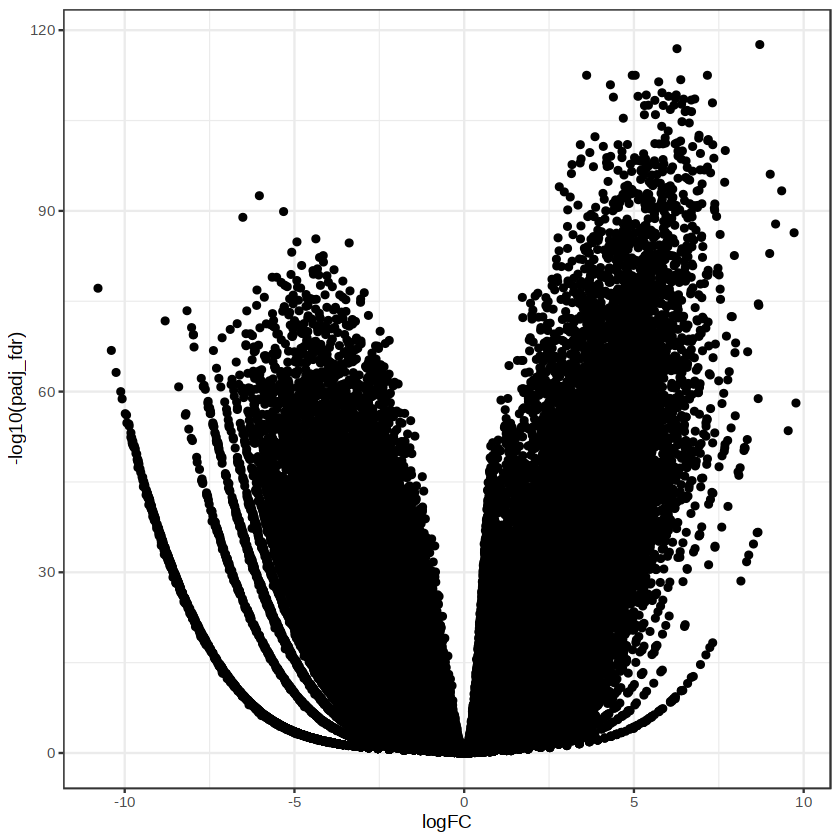

In [263]:
ggplot(differential_peaks_filt, aes(logFC, -log10(padj_fdr))) +
    geom_point() + theme_bw()

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


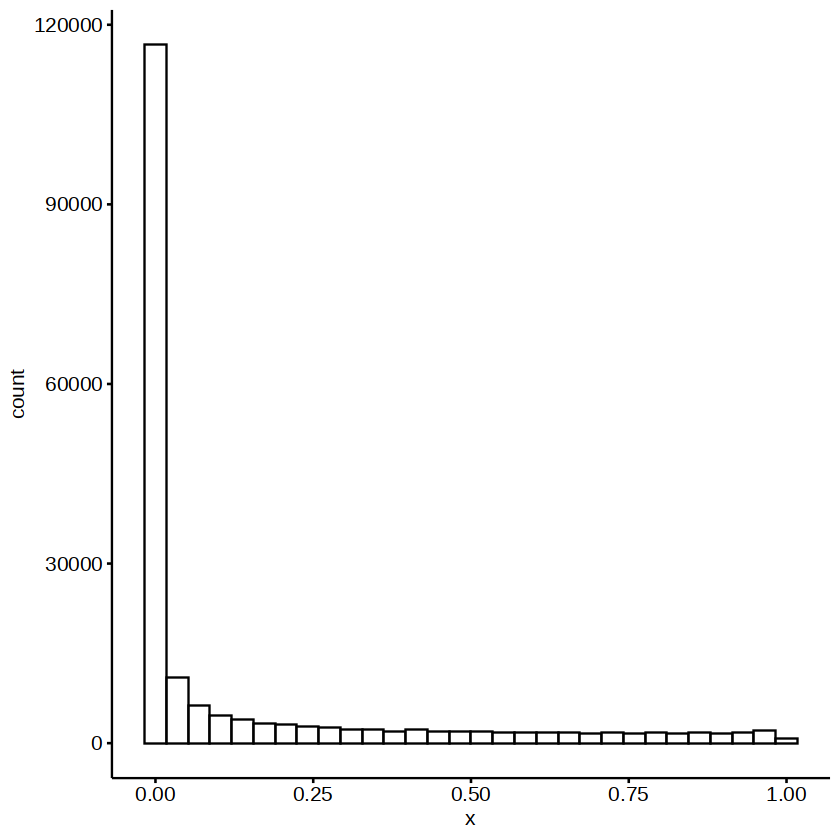

In [258]:
gghistogram(differential_peaks_filt$padj_fdr)

In [265]:
differential_metacells = fread(file.path(io$basedir, 'results/atac/archR/differential/metacells/celltype/PeakMatrix/PeakMatrix_Epiblast_vs_Endothelium.txt.gz'))

Warning message:
“Removed 27388 rows containing missing values (`geom_point()`).”


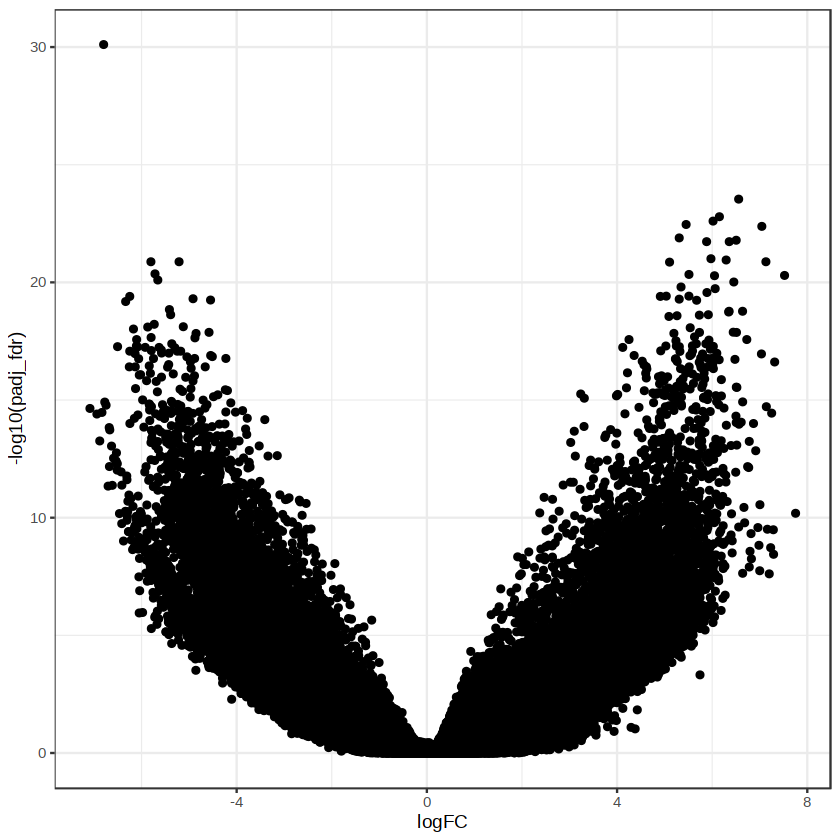

In [264]:
ggplot(differential_metacells, aes(logFC, -log10(padj_fdr))) +
    geom_point() + theme_bw()

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”
Warning message:
“Removed 27388 rows containing non-finite values (`stat_bin()`).”


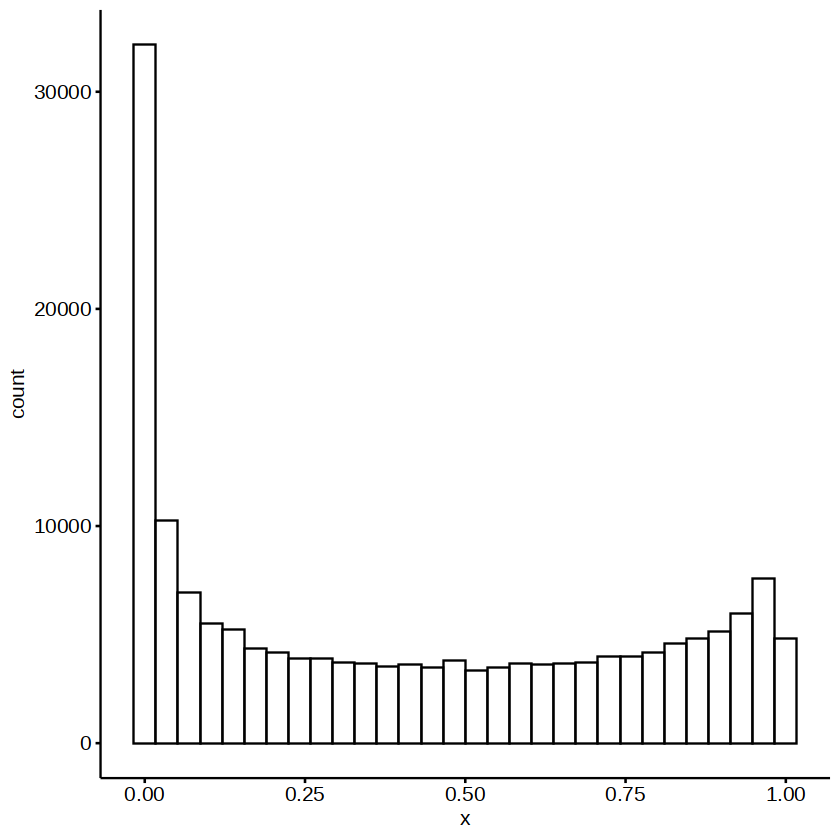

In [261]:
gghistogram(differential_metacells$padj_fdr)

In [276]:
# using the ones from metacells to determine most differential peaks
epi_peaks = parse_peaks(differential_metacells[order(-logFC), feature] %>% head(.,n=200))
endo_peaks = parse_peaks(differential_metacells[order(logFC), feature] %>% head(.,n=200))

epi_fa = mclapply(1:nrow(epi_peaks), get_fa_ss, peakset=epi_peaks, mc.cores=24) %>% unlist()
writeLines(epi_fa , sprintf('%s/Epiblast_inspection.fa', args$outdir))

endo_fa = mclapply(1:nrow(endo_peaks), get_fa_ss, peakset=endo_peaks, mc.cores=24) %>% unlist()
writeLines(endo_fa , sprintf('%s/Endothelium_inspection.fa', args$outdir))

In [277]:
head(epi_peaks)

peak,chr,centre,start,end,new_peak
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
chr2:11431797-11432397,chr2,11432097,11431973,11432221,chr2:11431973-11432221
chr7:105228036-105228636,chr7,105228336,105228212,105228460,chr7:105228212-105228460
chr10:60888454-60889054,chr10,60888754,60888630,60888878,chr10:60888630-60888878
chr14:25208410-25209010,chr14,25208710,25208586,25208834,chr14:25208586-25208834
chr1:91961113-91961713,chr1,91961413,91961289,91961537,chr1:91961289-91961537
chr1:181453951-181454551,chr1,181454251,181454127,181454375,chr1:181454127-181454375
